In [9]:
# Specify the checkpoint files you want to analyze
# Example: ['evaluation_checkpoint_beauty.json', 'evaluation_checkpoint_books.json']
CHECKPOINT_FILES = ['evaluation_checkpoint_movielens_gpt35_50length.json']


In [10]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Any
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict

def load_checkpoint(file_path: str) -> Dict[str, Any]:
    """Load a checkpoint JSON file."""
    with open(file_path, 'r') as f:
        return json.load(f)

def calculate_raw_llm_accuracy(checkpoint_data: Dict[str, Any]) -> tuple[float, float]:
    """
    Calculate raw LLM accuracy - how often target_item is in position 1 across all users and trials.
    Returns mean accuracy and variance across users.
    """
    user_accuracies = []
    
    # For each user
    for user_result in checkpoint_data['all_user_results']:
        target_item = user_result['target_item']
        correct_at_first = 0
        total_trials = len(user_result['raw_llm_data'])
        
        # Check each LLM trial
        for trial in user_result['raw_llm_data']:
            # Get the first ranked item from llm_reranked_list
            if trial['llm_reranked_list'] and trial['llm_reranked_list'][0]['title'] == target_item:
                correct_at_first += 1
                
        if total_trials > 0:
            accuracy = correct_at_first / total_trials
            user_accuracies.append(accuracy)
    
    return np.mean(user_accuracies), np.var(user_accuracies)

def apply_borda_count(user_result: Dict[str, Any]) -> Dict[str, float]:
    """
    Apply Borda count using debiased scores from all trials.
    Returns dictionary mapping items to their average Borda scores.
    """
    borda_scores = defaultdict(float)
    num_trials = len(user_result['raw_llm_data'])
    
    if num_trials == 0:
        return {}
        
    # Get number of candidates from first trial
    num_candidates = len(user_result['raw_llm_data'][0]['original_candidate_list'])
    
    # For each trial
    for trial in user_result['raw_llm_data']:
        # Sort candidates by debiased score
        candidates = sorted(
            trial['original_candidate_list'],
            key=lambda x: x['llm_rank'],
            reverse=False  # Higher score is better
        )
        
        # Apply Borda count scoring
        for rank, candidate in enumerate(candidates):
            title = candidate['title']
            borda_score = num_candidates - rank  # Higher rank = more points
            borda_scores[title] += borda_score
            
    # Calculate average scores
    avg_borda_scores = {
        title: score / num_trials 
        for title, score in borda_scores.items()
    }
    
    return avg_borda_scores

def calculate_borda_accuracy(checkpoint_data: Dict[str, Any]) -> tuple[float, float]:
    """
    Calculate accuracy using Borda count on all trials.
    Returns mean accuracy and standard error across users.
    """
    user_accuracies = []
    
    # For each user
    for user_result in checkpoint_data['all_user_results']:
        target_item = user_result['target_item']
        
        # Get Borda scores
        borda_scores = apply_borda_count(user_result)
        if not borda_scores:
            continue
            
        # Check if target item has highest score
        top_item = max(borda_scores.items(), key=lambda x: x[1])[0]
        accuracy = 1.0 if top_item == target_item else 0.0
        user_accuracies.append(accuracy)
    
    return np.mean(user_accuracies), np.std(user_accuracies) / np.sqrt(len(user_accuracies))


In [11]:
# Analyze specified checkpoint files
if not CHECKPOINT_FILES:
    print("No checkpoint files specified. Please set CHECKPOINT_FILES in the cell above.")
else:
    results = []
    
    for checkpoint_file in CHECKPOINT_FILES:
        try:
            # Load checkpoint data
            checkpoint_data = load_checkpoint(checkpoint_file)
            
            # Calculate raw LLM accuracy
            raw_mean, raw_var = calculate_raw_llm_accuracy(checkpoint_data)
            
            # Calculate Borda count accuracy
            borda_mean, borda_se = calculate_borda_accuracy(checkpoint_data)
            
            # Get some additional stats
            n_users = len(checkpoint_data['all_user_results'])
            total_trials = sum(len(user['raw_llm_data']) 
                             for user in checkpoint_data['all_user_results'])
            avg_trials_per_user = total_trials / n_users if n_users > 0 else 0
            
            # Store results
            results.append({
                'checkpoint': Path(checkpoint_file).name,
                'n_users': n_users,
                'total_trials': total_trials,
                'avg_trials_per_user': avg_trials_per_user,
                'raw_accuracy_mean': raw_mean,
                'raw_accuracy_std': np.sqrt(raw_var),
                'borda_accuracy_mean': borda_mean,
                'borda_accuracy_se': borda_se,
                'borda_accuracy_ci': 1.96 * borda_se  # 95% confidence interval
            })
            
            print(f"\nResults for {Path(checkpoint_file).name}:")
            print(f"Number of users: {n_users}")
            print(f"Total trials: {total_trials} ({avg_trials_per_user:.1f} per user)")
            print(f"Raw LLM Accuracy: {raw_mean:.3f} ± {np.sqrt(raw_var):.3f}")
            print(f"Borda Count Accuracy: {borda_mean:.3f} ± {1.96 * borda_se:.3f} (95% CI)")
            
        except Exception as e:
            print(f"\nError processing {checkpoint_file}: {str(e)}")

    if results:
        # Convert results to DataFrame
        results_df = pd.DataFrame(results)
        print("\nSummary of all results:")
        print(results_df)
        
        # Save results
        timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
        output_file = f'checkpoint_analysis_results_{timestamp}.csv'
        results_df.to_csv(output_file, index=False)
        print(f"\nResults have been saved to '{output_file}'")



Results for evaluation_checkpoint_movielens_gpt35_50length.json:
Number of users: 200
Total trials: 4000 (20.0 per user)
Raw LLM Accuracy: 0.126 ± 0.148
Borda Count Accuracy: 0.205 ± 0.056 (95% CI)

Summary of all results:
                                          checkpoint  n_users  total_trials  \
0  evaluation_checkpoint_movielens_gpt35_50length...      200          4000   

   avg_trials_per_user  raw_accuracy_mean  raw_accuracy_std  \
0                 20.0            0.12625          0.147981   

   borda_accuracy_mean  borda_accuracy_se  borda_accuracy_ci  
0                0.205           0.028546            0.05595  

Results have been saved to 'checkpoint_analysis_results_20250726_211500.csv'


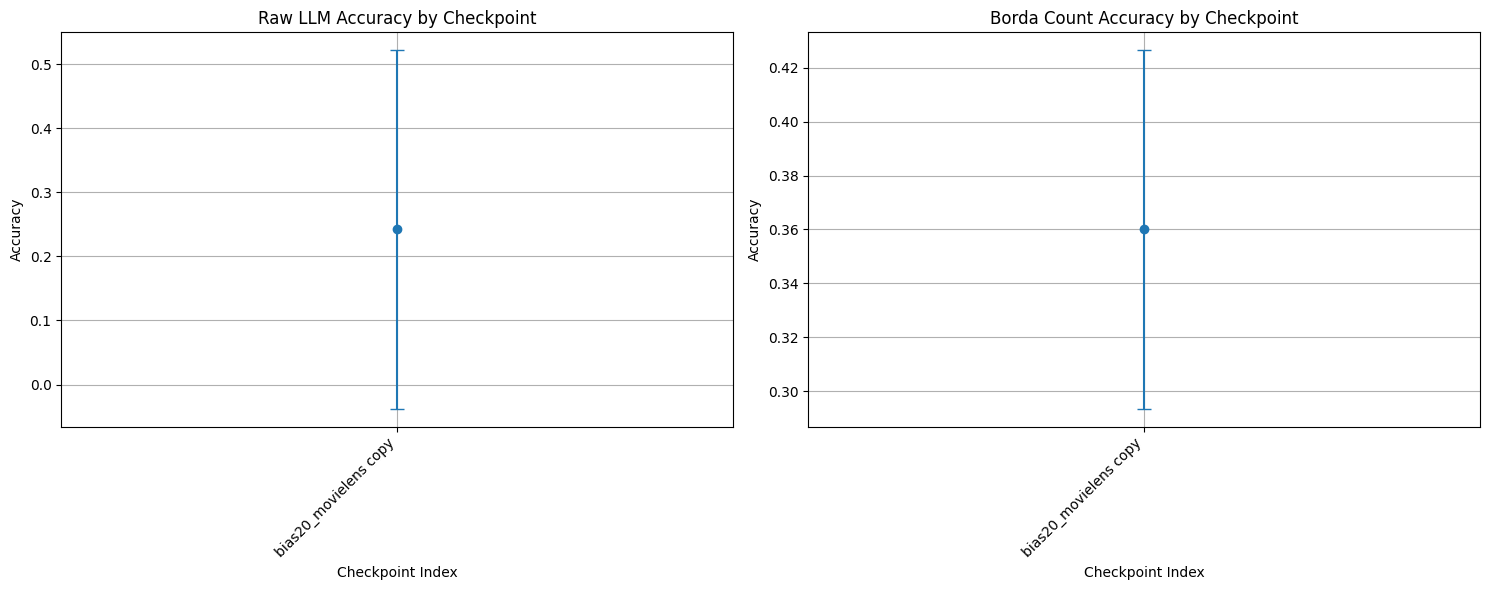

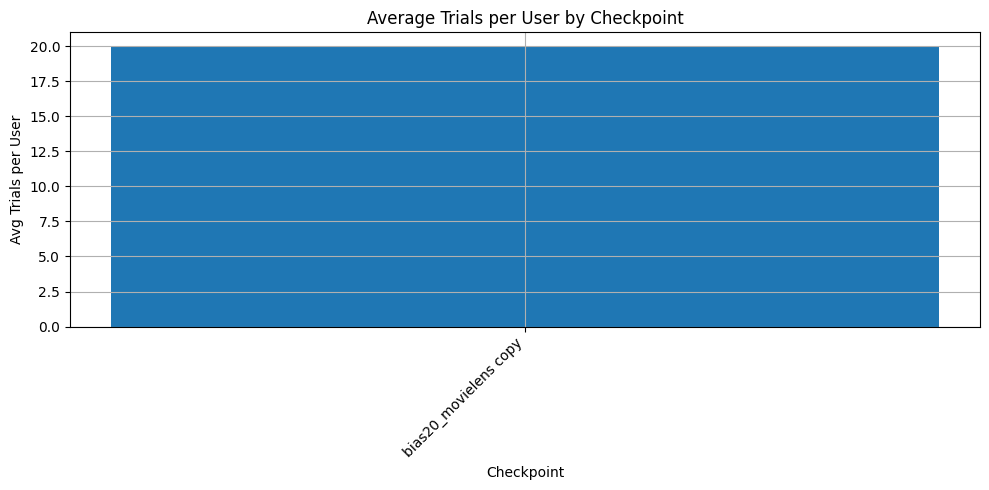

In [8]:
# Visualize results if any checkpoints were analyzed
if 'results' in locals() and results:
    plt.figure(figsize=(15, 6))

    # Plot raw accuracies
    plt.subplot(1, 2, 1)
    plt.errorbar(range(len(results)), 
                [r['raw_accuracy_mean'] for r in results],
                yerr=[r['raw_accuracy_std'] for r in results],
                fmt='o', capsize=5)
    plt.title('Raw LLM Accuracy by Checkpoint')
    plt.xlabel('Checkpoint Index')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.xticks(range(len(results)), 
               [r['checkpoint'].replace('evaluation_checkpoint_', '').replace('.json', '') 
                for r in results],
               rotation=45, ha='right')

    # Plot Borda count accuracies
    plt.subplot(1, 2, 2)
    plt.errorbar(range(len(results)), 
                [r['borda_accuracy_mean'] for r in results],
                yerr=[r['borda_accuracy_ci'] for r in results],
                fmt='o', capsize=5)
    plt.title('Borda Count Accuracy by Checkpoint')
    plt.xlabel('Checkpoint Index')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.xticks(range(len(results)), 
               [r['checkpoint'].replace('evaluation_checkpoint_', '').replace('.json', '') 
                for r in results],
               rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    # Additional visualization: trials per user distribution
    if len(results) > 0:
        plt.figure(figsize=(10, 5))
        plt.bar(range(len(results)), 
                [r['avg_trials_per_user'] for r in results])
        plt.title('Average Trials per User by Checkpoint')
        plt.xlabel('Checkpoint')
        plt.ylabel('Avg Trials per User')
        plt.grid(True)
        plt.xticks(range(len(results)), 
                   [r['checkpoint'].replace('evaluation_checkpoint_', '').replace('.json', '') 
                    for r in results],
                   rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
